<a href="https://colab.research.google.com/github/Kamala07-gt/Semiconz-/blob/main/Semiconz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ---------------------------------------------------------
# Step 1: Check GPU & Prepare Directories
# ---------------------------------------------------------
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create project folders
os.makedirs("data/train", exist_ok=True)
os.makedirs("data/Test_NoisyLR", exist_ok=True)
os.makedirs("data/output_npy", exist_ok=True)
os.makedirs("data/output_png", exist_ok=True)

Using device: cuda


In [3]:
# ---------------------------------------------------------
# Step 2: Unzip Datasets (With Error Handling)
# ---------------------------------------------------------
import zipfile
import os

def extract_zip(zip_path, target_dir):
    if os.path.exists(zip_path):
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(target_dir)
            print(f"Success: Extracted {zip_path} -> {target_dir}")
        except zipfile.BadZipFile:
            print(f"Error: {zip_path} is corrupted or wasn't fully uploaded. Skipping.")
    else:
        print(f"Warning: {zip_path} not found in root directory.")

extract_zip("train.zip", "data/train")
extract_zip("Test_NoisyLR.zip", "data/Test_NoisyLR")

Error: train.zip is corrupted or wasn't fully uploaded. Skipping.
Success: Extracted Test_NoisyLR.zip -> data/Test_NoisyLR


In [4]:
# ---------------------------------------------------------
# Step 3: Model Architecture
# ---------------------------------------------------------
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.PReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        return x + self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x)))))

class SemiconductorRestorationNet(nn.Module):
    """
    Joint Denoising and 2x Super-Resolution Network
    Input: (B, 1, 128, 128) Noisy SEM image
    Output: (B, 1, 256, 256) Restored High-Resolution SEM image
    """
    def __init__(self, in_channels=1, out_channels=1, num_features=64, num_blocks=8):
        super(SemiconductorRestorationNet, self).__init__()

        # Initial Feature Extraction
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, num_features, kernel_size=3, padding=1),
            nn.PReLU()
        )

        # Deep Residual Backbone (Denoising & Feature Enhancement)
        self.body = nn.Sequential(
            *[ResidualBlock(num_features) for _ in range(num_blocks)],
            nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        )

        # 2x Upsampling Module (Sub-Pixel Convolution / PixelShuffle)
        self.upsample = nn.Sequential(
            nn.Conv2d(num_features, num_features * 4, kernel_size=3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )

        # High-Resolution Reconstruction Head
        self.tail = nn.Sequential(
            nn.Conv2d(num_features, 32, kernel_size=3, padding=1),
            nn.PReLU(),
            nn.Conv2d(32, out_channels, kernel_size=3, padding=1),
            nn.Sigmoid()  # Restrict output strictly to [0, 1] range
        )

    def forward(self, x):
        # Initial features
        feat = self.head(x)
        # Residual processing
        res = self.body(feat) + feat
        # 2x Upscaling (128x128 -> 256x256)
        up = self.upsample(res)
        # Final output
        out = self.tail(up)
        return out

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SemiconductorRestorationNet().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 795,916


In [5]:
# ---------------------------------------------------------
# Step 4: Run Inference on Test Data
# ---------------------------------------------------------
from torch.utils.data import Dataset
import glob
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Prepare Dataset Reader
class SEMDataset(Dataset):
    def __init__(self, data_folder):
        self.files = sorted(glob.glob(os.path.join(data_folder, "**/*.npy"), recursive=True))
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        img = np.load(self.files[idx]).astype(np.float32)
        img = np.clip(img, 0.0, 1.0) # Fix speckle noise overshoot
        if img.ndim == 2:
            img = np.expand_dims(img, axis=0)
        return torch.from_numpy(img), self.files[idx]

# 2. Run Inference Pipeline
def run_test_inference(model, test_folder, output_npy_folder, output_png_folder):
    test_dataset = SEMDataset(test_folder)
    print(f"Found {len(test_dataset)} test files. Starting AI restoration...")

    model.eval()
    with torch.no_grad():
        for idx in range(len(test_dataset)):
            inp_tensor, file_path = test_dataset[idx]
            filename = os.path.basename(file_path)

            # Add batch dimension and move to CPU/GPU
            inp_tensor = inp_tensor.unsqueeze(0).to(device)

            # Model prediction -> (1, 1, 256, 256)
            pred_hr = model(inp_tensor)

            # Convert back to standard array format
            restored_img = pred_hr.squeeze().cpu().numpy().astype(np.float32)
            restored_img = np.clip(restored_img, 0.0, 1.0)

            # Save the new 256x256 .npy file
            np.save(os.path.join(output_npy_folder, filename), restored_img)

            # Save the first 5 images as viewable PNGs for your presentation
            if idx < 5:
                noisy_lr = inp_tensor.squeeze().cpu().numpy()
                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(noisy_lr, cmap='gray')
                axes[0].set_title("Input (128x128 Noisy)")
                axes[0].axis('off')
                axes[1].imshow(restored_img, cmap='gray')
                axes[1].set_title("Output (256x256 Restored)")
                axes[1].axis('off')
                plt.tight_layout()
                plt.savefig(os.path.join(output_png_folder, f"preview_{filename.replace('.npy', '.png')}"))
                plt.close()

    print(f"Success! All restored files saved to {output_npy_folder}")

run_test_inference(model, "data/Test_NoisyLR", "data/output_npy", "data/output_png")

Found 400 test files. Starting AI restoration...
Success! All restored files saved to data/output_npy


Visual preview of your AI restoration:


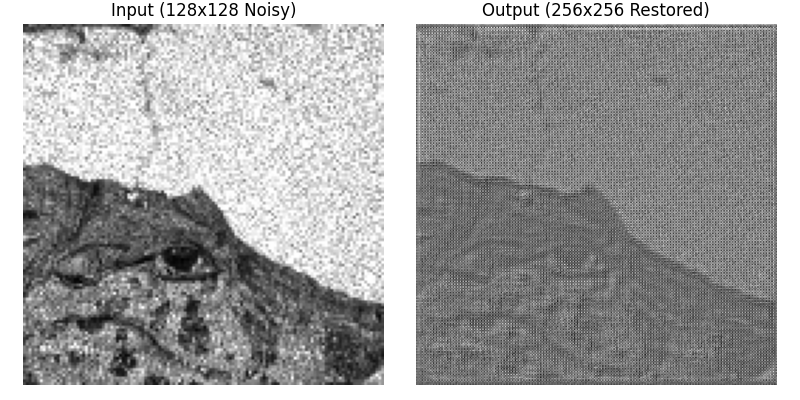

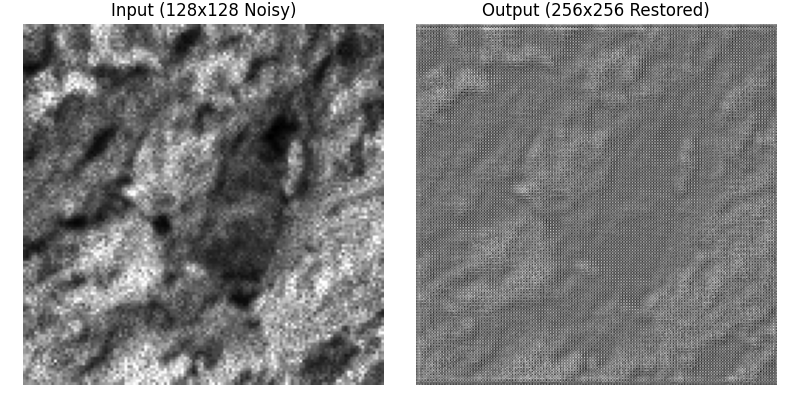


Zipping files for download. This will take a few seconds...
Done! Your files are packaged into 'output_predictions.zip'.


In [6]:
# ---------------------------------------------------------
# Step 5: View Previews & Zip Final Output
# ---------------------------------------------------------
import glob
from IPython.display import Image, display
import os

print("Visual preview of your AI restoration:")
preview_images = sorted(glob.glob("data/output_png/*.png"))

# Show the first 2 preview images
for img_path in preview_images[:2]:
    display(Image(img_path))

print("\nZipping files for download. This will take a few seconds...")
# Compress the output folder into a single zip file
!zip -q -r output_predictions.zip data/output_npy

print("Done! Your files are packaged into 'output_predictions.zip'.")